# Week 2: Hidden Anomalies in Observed Data

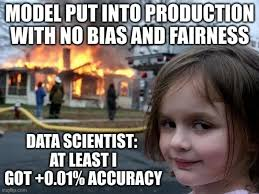

You receive three CSV files from a new collection of the same ACSIncome task:

- `week2_train_observed.csv`
- `week2_validation_observed.csv`
- `week2_test_features.csv`

You have received three new CSV files from a recent data collection effort for the ACSIncome task. However, this data was collected "in the wild" and has not been vetted. It may contain undocumented data-quality issues, distribution shifts, or inconsistent labels. 

You are **not** told whether a problem exists, what features are affected, or what caused the issues. Your task is to act and audit: you must explore the data, design robust checks to uncover issues, and critically interpret your findings to hypothesize what might be going wrong in the data pipeline. 

Do not jump directly to mitigation. A good audit strictly distinguishes between *observed evidence*, *hypotheses*, and *conclusions*.

In [ ]:
%pip -q install fairlearn cleanlab scikit-learn pandas matplotlib seaborn

In [ ]:
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

RANDOM_STATE = 42
DATA_DIR = Path("data")  # TODO: change if necessary

train = pd.read_csv(DATA_DIR / "week2_train_observed.csv")
validation = pd.read_csv(DATA_DIR / "week2_validation_observed.csv")
test_features = pd.read_csv(DATA_DIR / "week2_test_features.csv")

print(train.shape, validation.shape, test_features.shape)
display(train.head())

(18000, 15) (6000, 15) (6000, 14)


,row_id,AGEP,COW,SCHL,MAR,OCCP,POBP,RELP,WKHP,SEX,RAC1P,SEX_group,RACE_group,SURVEY_BATCH,income_observed
0,0,23.0,1.0,20.0,5.0,9130.0,48.0,2.0,40.0,1.0,1.0,Male,White,B04,0
1,1,57.0,1.0,21.0,1.0,3255.0,301.0,1.0,35.0,2.0,1.0,Female,White,B06,1
2,2,29.0,1.0,21.0,1.0,6800.0,6.0,0.0,48.0,1.0,1.0,Male,White,B02,1
3,3,42.0,6.0,17.0,1.0,6200.0,313.0,1.0,40.0,1.0,1.0,Male,White,B04,0
4,4,67.0,1.0,20.0,1.0,3601.0,48.0,0.0,6.0,2.0,2.0,Female,Black,B08,0


Hints: Design checks for schema, missingness, duplicates, impossible values, group sizes, target prevalence, and feature drift. Do not assume a column is safe merely because its name sounds administrative.

In [86]:
# Remove "SEX" and "RAC1P" as they are duplicate columns
if "SEX" in train.columns:
    train = train.drop(columns=["SEX"])
if "RAC1P" in train.columns:
    train = train.drop(columns=["RAC1P"])
if "SEX" in validation.columns:
    validation = validation.drop(columns=["SEX"])
if "RAC1P" in validation.columns:
    validation = validation.drop(columns=["RAC1P"])
if "SEX" in test_features.columns:
    test_features = test_features.drop(columns=["SEX"])
if "RAC1P" in test_features.columns:
    test_features = test_features.drop(columns=["RAC1P"])

In [88]:
# TODO: implement a reusable dataset summary.
def dataset_summary(df, label=None):
    """
    Generates a comprehensive diagnostic summary of the dataset.
    """
    summary = {}
    
    # Schema & Missingness
    # Assesses data types and exact null counts/percentages across all columns.
    schema_df = pd.DataFrame({
        'Data Type': df.dtypes,
        'Missing Count': df.isnull().sum(),
        'Missing (%)': (df.isnull().sum() / len(df)) * 100,
        'Unique Count': df.nunique()
    })
    summary['schema_and_missingness'] = schema_df
    
    # Duplicates
    # Checks for fully duplicated rows.
    summary['exact_duplicates'] = df.duplicated().sum()
    
    # Impossible Values (Numeric)
    # Extracts min, max, and percentiles to easily spot negative ages, percentages > 100, etc.
    numeric_cols = df.select_dtypes(include=[np.number]).columns
    if len(numeric_cols) > 0:
        summary['numeric_distributions'] = df[numeric_cols].describe(
            percentiles=[0.01, 0.5, 0.99]
        ).T[['min', '1%', '50%', '99%', 'max', 'mean']]
        
    # Group Sizes (Categorical)
    # Identifies rare classes or dominant single values in categorical/object features.
    cat_cols = df.select_dtypes(exclude=[np.number]).columns
    cat_summary = {}
    for col in cat_cols:
        # Calculate percentages of the categories
        percentages = df[col].value_counts(dropna=False, normalize=True).head() * 100
        cat_summary[col] = percentages.to_dict()
    summary['categorical_top_groups'] = cat_summary
    
    # Target Prevalence
    # Checks class imbalance or continuous target distribution if a label is specified.
    if label and label in df.columns:
        if pd.api.types.is_numeric_dtype(df[label]) and df[label].nunique() > 10:
            # If the target is a numeric type
            summary['target_prevalence'] = df[label].describe()
        else:
            # If the target is a string or similar non-numeric type
            summary['target_prevalence'] = df[label].value_counts(dropna=False, normalize=True) * 100
            
    return summary

def print_summary(summary, title):
    print(f"--- {title} ---")
    
    print("\n--- Data Schema & Missingness ---")
    print(summary['schema_and_missingness'])

    print("\n--- Numeric Percentiles (Check for Impossible Values) ---")
    print(summary['numeric_distributions'])

    print("\n--- Exact Duplicate Rows ---")
    print(summary['exact_duplicates'])

    print("\n--- Group Sizes ---")
    print(summary['categorical_top_groups'])

    if 'target_prevalence' in summary.keys():
        print("\n--- Target Prevalence ---")
        print(summary['target_prevalence'])

def check_feature_drift(train, validation, test_features):
    palette = {
        "train": "#013220",       # Dark Green
        "validation": "#d95f02",  # Muted Orange
        "test": "#7570b3"         # Muted Purple
    }
    datasets = {"train": train, "validation": validation, "test": test_features}
    feature_columns = [c for c in train.columns if c not in ["row_id", "income_observed"]]

    fig, axes = plt.subplots(len(feature_columns) // 3, 3, figsize=(15, 3 * (len(feature_columns) // 3)))
    axes = axes.flatten()

    for ax, col in zip(axes, feature_columns):
        if pd.api.types.is_numeric_dtype(train[col]):
            for name, df in datasets.items():
                ax.hist(df[col].dropna(), bins=25, alpha=0.5, density=True, label=name, color=palette[name])
        else:
            props = pd.DataFrame({
                name: df[col].value_counts(normalize=True) for name, df in datasets.items()
            })
            colors = [palette[name] for name in props.columns]
            props.plot(kind="bar", ax=ax, legend=False, color=colors)

        ax.set_title(col)
        ax.legend()

    plt.tight_layout()
    plt.show()

In [89]:
print_summary(summary=dataset_summary(train, label='income_observed'), title="Training Data")
print("----------------------------------------------------------")
print_summary(summary=dataset_summary(validation, label='income_observed'), title="Validation Data")
print("----------------------------------------------------------")
print_summary(summary=dataset_summary(test_features, label='income_observed'), title="Test Features")

--- Training Data ---

--- Data Schema & Missingness ---
                Data Type  Missing Count  Missing (%)  Unique Count
row_id              int64              0          0.0         18000
AGEP              float64              0          0.0            73
COW               float64              0          0.0             8
SCHL              float64              0          0.0            24
MAR               float64              0          0.0             5
OCCP              float64              0          0.0           515
POBP              float64              0          0.0           184
RELP              float64              0          0.0            18
WKHP              float64              0          0.0            93
SEX_group             str              0          0.0             2
RACE_group            str              0          0.0             9
SURVEY_BATCH          str              0          0.0             8
income_observed     int64              0          0.0      

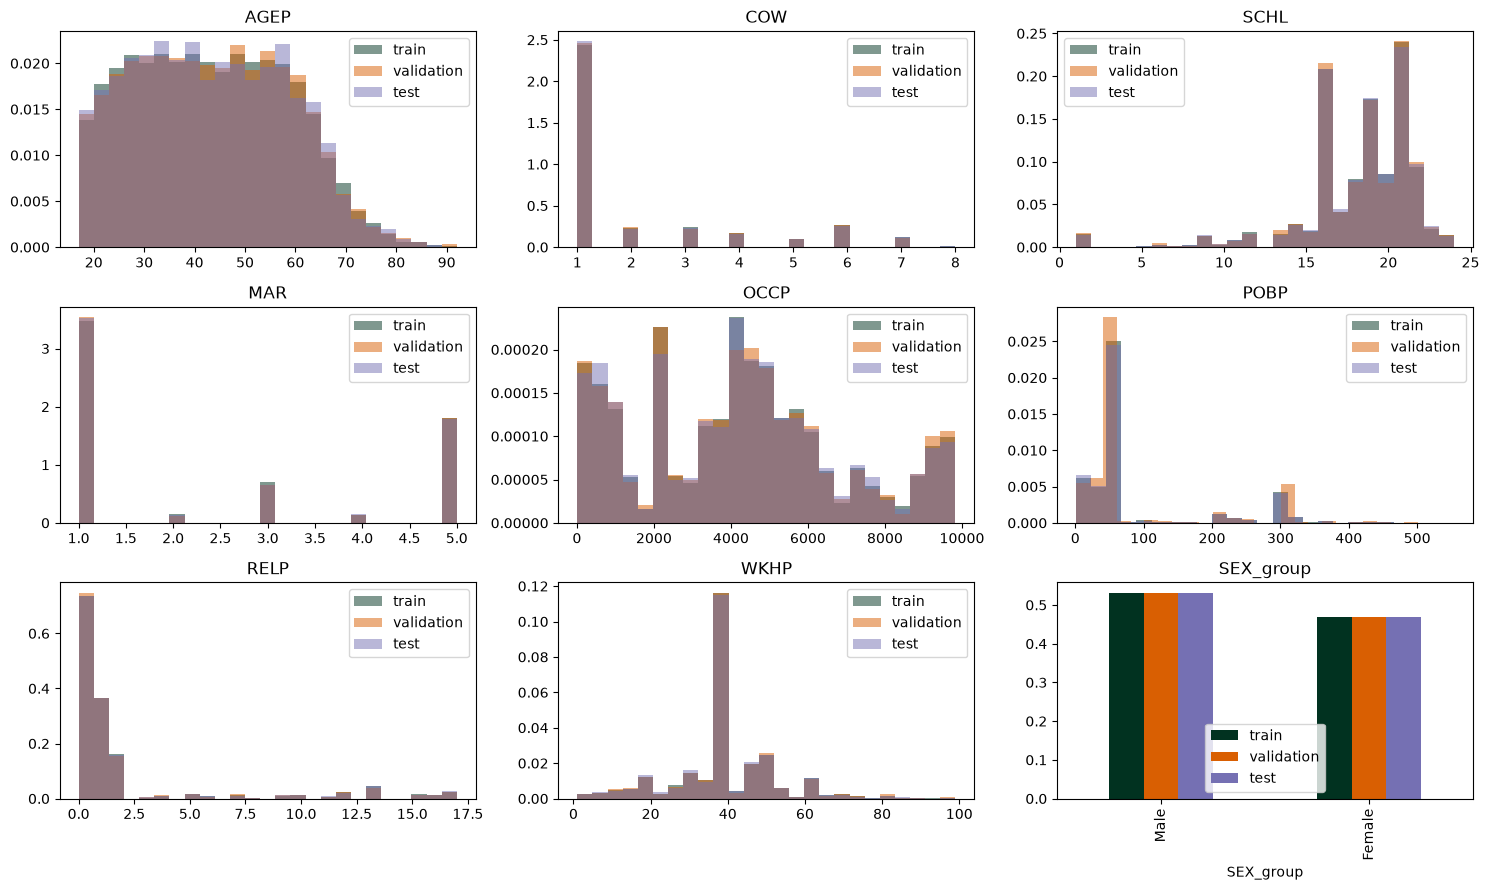

In [90]:
check_feature_drift(train, validation, test_features)

Hints: Build at least two models, including a simple interpretable baseline. Decide which features belong in the model. Keep `row_id` out of the predictive feature set. Keep sensitive attributes available for auditing even if you exclude them from prediction.

In [91]:
from sklearn.metrics import accuracy_score, balanced_accuracy_score, confusion_matrix, precision_score, recall_score, brier_score_loss, log_loss
from fairlearn.metrics import MetricFrame, selection_rate, count, equalized_odds_difference, equalized_odds_ratio, demographic_parity_difference, demographic_parity_ratio


# TODO: implement robust metric functions.
def true_positive_rate(y_true, y_pred):
    return recall_score(y_true, y_pred, pos_label=1, zero_division=0)

def false_positive_rate(y_true, y_pred):
    tn, fp, fn, tp = confusion_matrix(y_true, y_pred, labels=[0,1]).ravel()
    denominator = tn + fp
    return fp / denominator if denominator > 0 else np.nan

def positive_predictive_value(y_true, y_pred):
    return precision_score(y_true, y_pred, pos_label=1, zero_division=0)

def negative_predictive_value(y_true, y_pred):
    tn, fp, fn, tp = confusion_matrix(y_true, y_pred, labels=[0,1]).ravel()
    denominator = tn + fn
    return tn / denominator  if denominator else np.nan

def ppv_difference(y_true, y_pred, sensitive_features):
    mf = MetricFrame(metrics=positive_predictive_value, y_true=y_true, y_pred=y_pred, sensitive_features=sensitive_features)
    return mf.difference(method='between_groups')

def npv_difference(y_true, y_pred, sensitive_features):
    mf = MetricFrame(metrics=negative_predictive_value, y_true=y_true, y_pred=y_pred, sensitive_features=sensitive_features)
    return mf.difference(method='between_groups')

def expected_calibration_error(y_true, y_proba, n_bins=10):
    bins = np.linspace(0.0, 1.0, n_bins + 1)
    binids = np.digitize(y_proba, bins) - 1
    ece = 0.0
    for i in range(n_bins):
        mask = binids == i
        if np.sum(mask) > 0:
            prop_in_bin = np.mean(mask)
            acc_in_bin = np.mean(y_true[mask])
            conf_in_bin = np.mean(y_proba[mask])
            ece += np.abs(conf_in_bin - acc_in_bin) * prop_in_bin
    return ece

LABEL_METRICS = {
    "count": count,
    "selection_rate": selection_rate,
    "accuracy": accuracy_score,
    "balanced_accuracy": balanced_accuracy_score,
    "tpr": true_positive_rate,
    "fpr": false_positive_rate,
    "ppv": positive_predictive_value,
    "npv": negative_predictive_value,
}
PROBA_METRICS = {
    "brier_score": brier_score_loss,
    "ece": expected_calibration_error
}


def fairness_summary(y_true, y_pred, sens_df, scores=None):
    # Compute metrics
    summary = {}
    label_mf = MetricFrame(
        metrics=LABEL_METRICS,
        y_true=y_true,
        y_pred=y_pred,
        sensitive_features=sens_df,
    )
    overall_report = pd.concat([label_mf.overall])
    group_report = pd.concat([label_mf.by_group], axis=1)
    
    if scores is not None:
        proba_mf = MetricFrame(
            metrics=PROBA_METRICS,
            y_true=y_true,
            y_pred=scores,
            sensitive_features=sens_df
        )
        overall_report = pd.concat([label_mf.overall, proba_mf.overall])
        group_report = pd.concat([label_mf.by_group, proba_mf.by_group], axis=1)
        
    summary['overall'] = overall_report
    summary['by_group'] = group_report
    
    disparity_summary = pd.Series({
            # --- INDEPENDENCE ---
            "independence_demographic_parity_diff": demographic_parity_difference(
                y_true=y_true, y_pred=y_pred, sensitive_features=sens_df
            ),
            "independence_demographic_parity_ratio": demographic_parity_ratio(
                y_true=y_true, y_pred=y_pred, sensitive_features=sens_df
            ),
            
            # --- SEPARATION ---
            "separation_equalized_odds_diff": equalized_odds_difference(
                y_true=y_true, y_pred=y_pred, sensitive_features=sens_df
            ),
            "separation_equalized_odds_ratio": equalized_odds_ratio(
                y_true=y_true, y_pred=y_pred, sensitive_features=sens_df
            ),
            
            # --- SUFFICIENCY ---
            "sufficiency_ppv_difference": ppv_difference(
                y_true=y_true, y_pred=y_pred, sensitive_features=sens_df
            ),
            "sufficiency_npv_difference": npv_difference(
                y_true=y_true, y_pred=y_pred, sensitive_features=sens_df
            ),
        })
    summary['disparity'] = disparity_summary
    return summary
    
def display_summary(summary, name=None):
    print("="*80)
    if name:
        print(f"Audit results for {name}:")
    print("=== Overall threshold metrics ===")
    display(summary['overall'])
    print("\n=== Group-Level Metrics ===")
    display(summary['by_group'])
    print("\n=== Fairness & Disparity Summary ===")
    display(summary['disparity'])

In [115]:
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.linear_model import LogisticRegression

LABEL = "income_observed"
# ID = "row_id"

# TODO: choose features and justify exclusions.
SENSITIVE = ["SEX_group"]
NUMERIC_FEATURES = ["AGEP", "SCHL", "WKHP"]
CATEGORICAL_FEATURES = ["COW", "MAR", "OCCP", "POBP", "RELP", "RACE_group"] + SENSITIVE
FEATURE_COLUMNS = NUMERIC_FEATURES + CATEGORICAL_FEATURES

groups = {group_val: (validation["SEX_group"] == group_val) for group_val in sorted(validation["SEX_group"].unique())}

# TODO: write a model factory that handles numeric and categorical columns.
def make_model(frame):
    numeric = [c for c in NUMERIC_FEATURES if c in frame.columns]
    categorical = [c for c in CATEGORICAL_FEATURES if c in frame.columns]
    prep = ColumnTransformer([
        ("num", StandardScaler(), numeric),
        ("cat", OneHotEncoder(handle_unknown="ignore"), categorical),
    ])
    return Pipeline([
        ("preprocess", prep),
        ("model", LogisticRegression(max_iter=1000)),
    ])

# TODO: fit a baseline on observed training labels and evaluate against observed validation labels.
lr_model = make_model(train)
lr_model.fit(train[FEATURE_COLUMNS], train[LABEL])

lr_val_pred = lr_model.predict(validation[FEATURE_COLUMNS])
lr_val_proba = lr_model.predict_proba(validation[FEATURE_COLUMNS])[:,1]
lr_val_acc = accuracy_score(validation[LABEL], lr_val_pred)

baseline_pred = (validation['SCHL'] >= 21).astype(int) # 21 Bachelor's Degree
baseline_val_acc = accuracy_score(validation["income_observed"], baseline_pred)

print("Logistic Regression Validation Accuracy:", lr_val_acc)
print("SCHL Baseline Accuracy:", baseline_val_acc)

Logistic Regression Validation Accuracy: 0.7955
SCHL Baseline Accuracy: 0.702


Compute overall and group-specific utility, selection rate, TPR, FPR, PPV, NPV, equalized-odds components, and probability metrics. Report counts and uncertainty. Explicitly label every result as being evaluated against $Y^{obs}$.

In [116]:
# TODO: construct MetricFrame for SEX_group and at least one intersection.
summary = fairness_summary(validation[LABEL], lr_val_pred, validation[SENSITIVE], scores=lr_val_proba)
display_summary(summary, name="Logistic Regression on Validation Set")

Audit results for Logistic Regression on Validation Set:
=== Overall threshold metrics ===


count                6000.000000
selection_rate          0.296167
accuracy                0.795500
balanced_accuracy       0.756076
tpr                     0.637089
fpr                     0.124937
ppv                     0.719190
npv                     0.827611
brier_score             0.140828
ece                     0.017822
dtype: float64


=== Group-Level Metrics ===


,count,selection_rate,accuracy,balanced_accuracy,tpr,fpr,ppv,npv,brier_score,ece
SEX_group,,,,,,,,,,
Female,2812.0,0.139758,0.803343,0.649106,0.371795,0.073583,0.590331,0.837950,0.133622,0.021834
Male,3188.0,0.434128,0.788582,0.784860,0.756874,0.187154,0.755780,0.813747,0.147185,0.015540



=== Fairness & Disparity Summary ===


independence_demographic_parity_diff     0.294370
independence_demographic_parity_ratio    0.321929
separation_equalized_odds_diff           0.385079
separation_equalized_odds_ratio          0.393169
sufficiency_ppv_difference               0.165450
sufficiency_npv_difference               0.024202
dtype: float64

### Mitigating observed bias

Hint: The Threshold Optimizer method in FairLearn (https://fairlearn.org/v0.5.0/api_reference/fairlearn.postprocessing.html) can be used to enforce e.g. the Equalized Odds criterion -- we have learned about how it works in week 2. But for now, apply the Threshold_Optimizer to mitigate bias according to one of your chosen criteria (using the "constraints" option). Repeat your fairness diagnostics for the updated model. Did the mitigation make the model more fair in all respects?

Calibration must name its target label. Compare group reliability curves and Brier scores against `income_observed`. Inspect whether apparent calibration differs by group and by score range.

Any more mitigation stratergies you could think of? Do they work on the observed data? 

In [ ]:
def calibration_table(y_true, y_proba, n_bins=15, min_bin_size=30):
    y_t = np.asarray(y_true).ravel()
    y_p = np.asarray(y_proba).ravel()
    data = pd.DataFrame({"y_true": y_t, "y_proba": y_p})
    
    bin_edges = np.linspace(0.0, 1.0, n_bins + 1)
    data["bin"] = pd.cut(
        data["y_proba"], bins=bin_edges, include_lowest=True
    )

    table = (
        data.groupby("bin", observed=False)
        .agg(
            mu_pred=("y_proba", "mean"),
            mu_obs=("y_true", "mean"),
            count=("y_true", "size"),
        )
        .reset_index()
    )

    table["gap"] = (table["mu_pred"] - table["mu_obs"]).abs()
    table["reliable"] = table["count"] >= min_bin_size
    return table


def grouped_calibration_tables(y_true, y_proba, groups, n_bins=10, min_bin_size=30):
    tables = {}
    for name, mask in groups.items():
        tables[name] = calibration_table(y_true[mask], y_proba[mask], n_bins=n_bins, min_bin_size=min_bin_size)
    return tables
    

def reliability_plot_from_ctable(c_tables, title="Reliability Curves"):
    plt.figure(figsize=(5, 5))
    plt.plot(
        [0, 1],
        [0, 1],
        linestyle="--",
        color="gray",
        label="Perfect Calibration"
    )

    for name, c_table in c_tables.items():
        plot_data = c_table.dropna(subset=["mu_pred", "mu_obs"])
        plt.plot(
            plot_data["mu_pred"],
            plot_data["mu_obs"],
            marker="o",
            label=name,
            linewidth=1.5,
        )

    plt.xlabel("Mean Predicted Probability", fontsize=12)
    plt.ylabel("Observed Positive Fractiom", fontsize=12)
    plt.title(title, fontsize=13, fontweight="bold")
    plt.xlim([-0.02, 1.02])
    plt.ylim([-0.02, 1.02])
    plt.grid(True, linestyle=":", alpha=0.6)
    plt.legend(fontsize=12)
    plt.tight_layout()
    plt.show()
    
    return c_tables
    
def reliability_plot(y_true, model_scores, n_bins=10, min_bin_size=30, title="Reliability Curves"):
    c_table_overall = calibration_table(y_true, model_scores, n_bins=n_bins, min_bin_size=min_bin_size)
    c_tables_grouped = grouped_calibration_tables(y_true, model_scores, groups=groups, n_bins=n_bins, min_bin_size=min_bin_size)

    c_tables = {"Overall": c_table_overall, **c_tables_grouped}

    reliability_plot_from_ctable(c_tables, title=title)

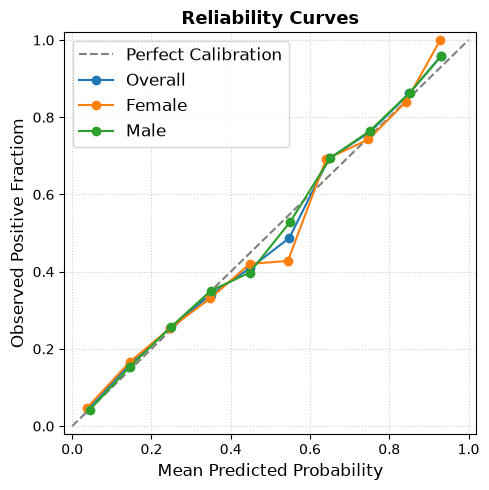

In [148]:
reliability_plot(validation[LABEL], lr_val_proba)

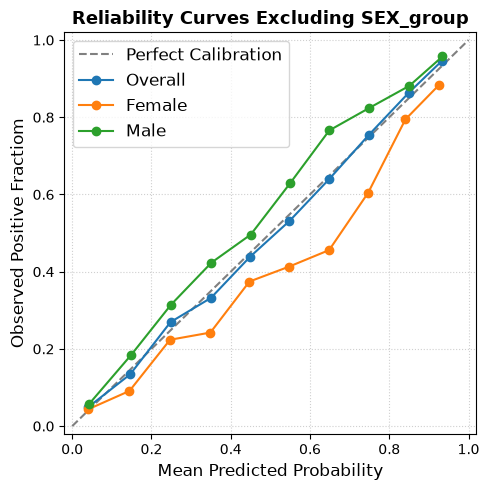

In [150]:
# Reliability Curves when excluding SEX_group
FEATURE_COLUMNS_NO_SENS_FEATURES = FEATURE_COLUMNS[:-len(SENSITIVE)]

lr_model_no_sens_features = make_model(train[FEATURE_COLUMNS_NO_SENS_FEATURES + [LABEL]])
lr_model_no_sens_features.fit(train[FEATURE_COLUMNS_NO_SENS_FEATURES], train[LABEL])

lr_val_pred_no_sens_features = lr_model_no_sens_features.predict(validation[FEATURE_COLUMNS_NO_SENS_FEATURES])
lr_val_proba_no_sens_features = lr_model_no_sens_features.predict_proba(validation[FEATURE_COLUMNS_NO_SENS_FEATURES])[:,1]

reliability_plot(validation[LABEL], lr_val_proba_no_sens_features, title="Reliability Curves Excluding SEX_group")

Does not appear to lack Sufficiency, overall or between sex groups.

In [ ]:
from fairlearn.postprocessing import ThresholdOptimizer
from sklearn.model_selection import train_test_split

# I should not fit the mitigator on the training set, but rather on the validation data to avoid data leakage.
# Therefore I will split the validation in two parts: one for fitting the mitigator and one for evaluating it.
val_calibrate, val_eval = train_test_split(
    validation, test_size=0.5, random_state=RANDOM_STATE, stratify=validation[LABEL]
)

mitigator = ThresholdOptimizer(
    estimator=lr_model,
    constraints="equalized_odds",
    predict_method="predict_proba",
    prefit=True,
)
mitigator.fit(
    val_calibrate[FEATURE_COLUMNS],
    val_calibrate[LABEL],
    sensitive_features=val_calibrate[SENSITIVE],
)

base_eval_pred = lr_model.predict(val_eval[FEATURE_COLUMNS])
base_eval_proba = lr_model.predict_proba(val_eval[FEATURE_COLUMNS])[:,1]
mitigated_pred = mitigator.predict(
    val_eval[FEATURE_COLUMNS],
    sensitive_features=val_eval[SENSITIVE],
    random_state=RANDOM_STATE,
)

summary_before = fairness_summary(val_eval[LABEL], base_eval_pred, val_eval[SENSITIVE])
summary_after = fairness_summary(val_eval[LABEL], mitigated_pred, val_eval[SENSITIVE])

display_summary(summary_before, name="Before Mitigation")
display_summary(summary_after, name="After Mitigation")

Audit results for Before Mitigation:
=== Overall threshold metrics ===


count                3000.000000
selection_rate          0.306000
accuracy                0.801667
balanced_accuracy       0.766663
tpr                     0.661017
fpr                     0.127692
ppv                     0.722222
npv                     0.836695
dtype: float64


=== Group-Level Metrics ===


,count,selection_rate,accuracy,balanced_accuracy,tpr,fpr,ppv,npv
SEX_group,,,,,,,,
Female,1382.0,0.143994,0.803907,0.653072,0.382353,0.076208,0.587940,0.840237
Male,1618.0,0.444376,0.799753,0.797759,0.783357,0.187839,0.759388,0.832036



=== Fairness & Disparity Summary ===


...

count                3000.000000
selection_rate          0.256000
accuracy                0.757000
balanced_accuracy       0.697878
tpr                     0.519442
fpr                     0.123686
ppv                     0.678385
npv                     0.784050
dtype: float64


=== Group-Level Metrics ===


,count,selection_rate,accuracy,balanced_accuracy,tpr,fpr,ppv,npv
SEX_group,,,,,,,,
Female,1382.0,0.200434,0.798119,0.690281,0.496732,0.116171,0.548736,0.860633
Male,1618.0,0.303461,0.721879,0.698474,0.529412,0.132465,0.751527,0.708962



=== Fairness & Disparity Summary ===


independence_demographic_parity_diff     0.103027
independence_demographic_parity_ratio    0.660494
separation_equalized_odds_diff           0.032680
separation_equalized_odds_ratio          0.876996
sufficiency_ppv_difference               0.202791
sufficiency_npv_difference               0.151672
dtype: float64

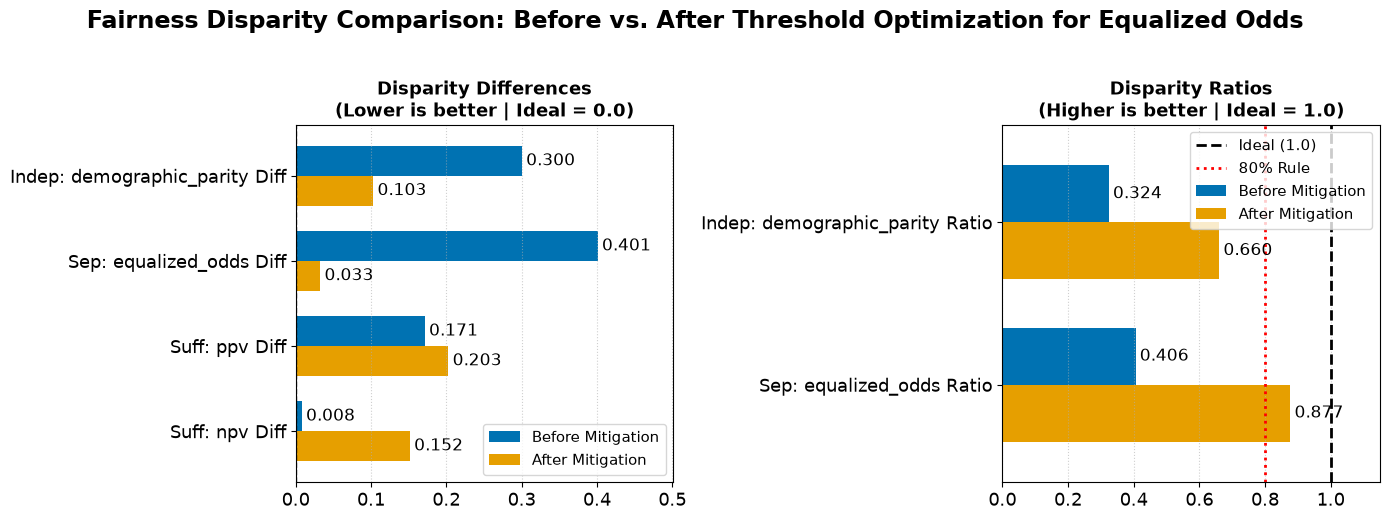

In [146]:
def plot_disparity_comparison(
    summary_before,
    summary_after,
    title="Fairness Disparity Comparison: Before vs. After Threshold Optimization for Equalized Odds",
):
    # Extract disparity series (handles dict or Series direct input)
    disp_before = (
        summary_before["disparity"]
        if isinstance(summary_before, dict)
        else summary_before
    )
    disp_after = (
        summary_after["disparity"]
        if isinstance(summary_after, dict)
        else summary_after
    )

    # Combine into DataFrame
    df = pd.DataFrame(
        {"Before Mitigation": disp_before, "After Mitigation": disp_after}
    )

    # Separate Differences from Ratios
    is_ratio = df.index.str.contains("_ratio")
    df_diffs = df[~is_ratio].copy()
    df_ratios = df[is_ratio].copy()

    # Clean up metric labels for visual readability
    def clean_labels(index):
        return [
            idx.replace("independence_", "Indep: ")
            .replace("separation_", "Sep: ")
            .replace("sufficiency_", "Suff: ")
            .replace("_demographic_parity", "")
            .replace("_equalized_odds", "")
            .replace("_difference", " Diff")
            .replace("_diff", " Diff")
            .replace("_ratio", " Ratio")
            for idx in index
        ]

    df_diffs.index = clean_labels(df_diffs.index)
    df_ratios.index = clean_labels(df_ratios.index)
    
    COLOR_BEFORE = "#0072B2"  # Strong Blue (Before)
    COLOR_AFTER = "#E69F00"  # Amber / Orange (After)
    COLOR_EEOC = "#CC79A7"  # Reddish Purple (EEOC 80% Reference Line)

    # Create figure with 2 subplots
    fig, axes = plt.subplots(
        1, 2, figsize=(14, 5), gridspec_kw={"width_ratios": [1, 1]}
    )

    # --- Subplot 1: Differences (Ideal = 0.0, Lower is Better) ---
    ax1 = axes[0]
    df_diffs.plot(kind="barh", ax=ax1, color=[COLOR_BEFORE, COLOR_AFTER], width=0.7)
    ax1.set_title(
        "Disparity Differences\n(Lower is better | Ideal = 0.0)",
        fontsize=13,
        fontweight="bold",
    )
    ax1.axvline(0.0, color="black", linestyle="--", linewidth=1, alpha=0.7)
    ax1.set_xlim(0, max(df_diffs.max().max() * 1.25, 0.4))
    ax1.invert_yaxis()  # Keep top-to-bottom order matching code
    ax1.grid(True, linestyle=":", alpha=0.6, axis="x")
    ax1.tick_params(axis="both", labelsize=13)  # Larger tick labels

    for container in ax1.containers:
        ax1.bar_label(container, fmt="%.3f", padding=3, fontsize=12)

    # --- Subplot 2: Ratios (Ideal = 1.0, Higher is Better) ---
    ax2 = axes[1]
    df_ratios.plot(kind="barh", ax=ax2, color=[COLOR_BEFORE, COLOR_AFTER], width=0.7)
    ax2.set_title(
        "Disparity Ratios\n(Higher is better | Ideal = 1.0)",
        fontsize=13,
        fontweight="bold",
    )
    ax2.axvline(
        1.0, color="black", linestyle="--", linewidth=2, label="Ideal (1.0)"
    )
    ax2.axvline(
        0.8, color="red", linestyle=":", linewidth=2, label="80% Rule"
    )
    ax2.set_xlim(0, 1.15)
    ax2.invert_yaxis()
    ax2.grid(True, linestyle=":", alpha=0.6, axis="x")
    ax2.tick_params(axis="both", labelsize=13)  # Larger tick labels

    for container in ax2.containers:
        ax2.bar_label(container, fmt="%.3f", padding=3, fontsize=12)

    # Legend & Formatting
    ax1.legend(loc="lower right", fontsize=11)
    ax2.legend(loc="upper right", fontsize=11)
    plt.suptitle(title, fontsize=17, fontweight="bold", y=1.03)
    plt.tight_layout()
    plt.show()


# Example Usage:
plot_disparity_comparison(summary_before, summary_after, title="Fairness Disparity Comparison: Before vs. After Threshold Optimization for Equalized Odds")

## Week 2 : What to think about?

1. Audit plan and model cards for your baselines.
2. Observed-label performance, fairness, and calibration.
3. Label-quality evidence ?
4. Instability evidence?
5. Two competing explanations for your findings.
7. A clear separation between **observed evidence**, **hypothesis**, and **conclusion**.

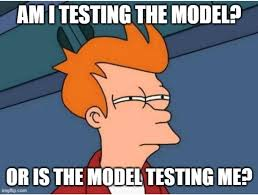

## 📝 Project 1 Submission Guidelines (Week 2 Contribution)

The investigations and hypotheses generated from this Week 2 notebook will form the second major section of your final A0 poster (~ another 1/3 of the poster).

When preparing your poster, ensure this section includes:
* Briefly outline the models and checks you used to establish performance and fairness baselines on the observed (but untrusted (?)) labels.
* *Highlight the most compelling evidence of data labels issue or generalizability issues you discovered (e.g., highly suspicious/unstable features, strange sub-group performances, or findings using popular frameworks).
* Present your strongest hypotheses explaining *why* these anomalies exist in the data. Clearly separate your observed data evidence from your conclusions about what real-world issues (such as systemic biases or collection flaws) might be causing them.
